<a href="https://colab.research.google.com/github/Arnold-XV/cvl_assignment2/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 Coffee Bean Detection & Classification

Implementasi ini menyelesaikan deteksi objek biji kopi (**roasted** vs **unroasted**)

Pipeline:
1. RGB → Grayscale (luminosity).
2. Static background thresholding (biner foreground/background).
3. Connected Component Labeling dengan Flood Fill BFS untuk bounding box.
4. Ekstraksi fitur mean intensity per bounding box.
5. Klasifikasi roasted/unroasted berbasis threshold intensitas.
6. Evaluasi dengan IoU dan confusion matrix.


# Dependencies

In [97]:
# Dependencies
import os
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1.Image Input

In [131]:
# Isi path file gambar real (.png/.jpg/.jpeg)
real_file_path = r"./allroaststages.jpg"
allowed_extensions = (".png", ".jpg", ".jpeg")

path_is_filled = isinstance(real_file_path, str) and len(real_file_path.strip()) > 0
path_has_valid_ext = real_file_path.lower().endswith(allowed_extensions) if path_is_filled else False
file_exists = os.path.exists(real_file_path) if path_is_filled else False
real_input_ready = path_is_filled and path_has_valid_ext and file_exists

print("Input Gambar")
print(f"Path gambar: {real_file_path}")

if not path_is_filled:
    print("Status: path gambar belum diisi.")
elif not path_has_valid_ext:
    print("Status: format file tidak valid. Gunakan .png, .jpg, atau .jpeg.")
elif not file_exists:
    print("Status: file belum ditemukan pada path tersebut.")
else:
    print("Status: gambar berhasil terinput dan siap diproses.")

print(f"Input ready: {real_input_ready}")

Input Gambar
Path gambar: ./allroaststages.jpg
Status: gambar berhasil terinput dan siap diproses.
Input ready: True


# 2.Function


In [132]:
def rgb_to_grayscale(rgb_image):
    """
    Konversi citra RGB (H x W x 3) -> grayscale (H x W) menggunakan luminosity:
    Y = 0.299R + 0.587G + 0.114B
    """
    height = len(rgb_image)
    width = len(rgb_image[0]) if height > 0 else 0

    gray = [[0 for _ in range(width)] for _ in range(height)]

    for y in range(height):
        for x in range(width):
            r, g, b = rgb_image[y][x]
            # Operasi matematika luminosity: kombinasi linear kanal warna.
            y_float = 0.299 * r + 0.587 * g + 0.114 * b
            gray[y][x] = int(y_float + 0.5)  # pembulatan ke integer terdekat

    return gray


def segment_foreground_threshold(gray_image, bg_val=110, t_diff=25):
    """
    Segmentasi berbasis selisih absolut terhadap background abu-abu (mid-tone):
    foreground = 1 jika |pixel - bg_val| > t_diff
    background = 0 jika |pixel - bg_val| <= t_diff
    """
    height = len(gray_image)
    width = len(gray_image[0]) if height > 0 else 0

    binary = [[0 for _ in range(width)] for _ in range(height)]

    for y in range(height):
        for x in range(width):
            # Operasi selisih absolut terhadap estimasi background.
            diff = gray_image[y][x] - bg_val
            abs_diff = diff if diff >= 0 else -diff
            # Operasi thresholding berbasis margin toleransi.
            binary[y][x] = 1 if abs_diff > t_diff else 0

    return binary


def connected_components_bboxes(binary_image, min_area=20):
    """
    Flood Fill BFS untuk Connected Component Labeling.
    Mengembalikan list bbox: (x_min, y_min, x_max, y_max, area)
    """
    height = len(binary_image)
    width = len(binary_image[0]) if height > 0 else 0

    visited = [[False for _ in range(width)] for _ in range(height)]
    bboxes = []

    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # 4-neighborhood

    for y in range(height):
        for x in range(width):
            if binary_image[y][x] == 1 and not visited[y][x]:
                queue = deque([(x, y)])
                visited[y][x] = True

                x_min, x_max = x, x
                y_min, y_max = y, y
                area = 0

                while queue:
                    cx, cy = queue.popleft()
                    area += 1  # Operasi hitung luas blob: jumlah piksel foreground.

                    # Operasi min/max untuk memperbarui batas bounding box.
                    x_min = cx if cx < x_min else x_min
                    x_max = cx if cx > x_max else x_max
                    y_min = cy if cy < y_min else y_min
                    y_max = cy if cy > y_max else y_max

                    for dx, dy in neighbors:
                        # Operasi translasi koordinat tetangga.
                        nx = cx + dx
                        ny = cy + dy

                        # Operasi validasi batas citra.
                        if 0 <= nx < width and 0 <= ny < height:
                            if binary_image[ny][nx] == 1 and not visited[ny][nx]:
                                visited[ny][nx] = True
                                queue.append((nx, ny))

                # Operasi filter area minimum untuk menghapus noise kecil.
                if area >= min_area:
                    bboxes.append((x_min, y_min, x_max, y_max, area))

    return bboxes


def mean_intensity_in_bbox(gray_image, binary_image, bbox):
    """
    Hitung mean intensity grayscale ter-mask pada area bbox (inklusif).
    bbox: (x_min, y_min, x_max, y_max, area_opt)
    """
    x_min, y_min, x_max, y_max = bbox[:4]

    intensity_sum = 0
    pixel_count = 0

    for y in range(y_min, y_max + 1):
        for x in range(x_min, x_max + 1):
            # Hanya hitung piksel foreground hasil segmentasi.
            if binary_image[y][x] == 1:
                intensity_sum += gray_image[y][x]
                pixel_count += 1

    # Operasi pembagian untuk rata-rata; aman dari pembagi nol.
    return intensity_sum / pixel_count if pixel_count > 0 else 0.0


def classify_roast_stage(mean_intensity):
    """
    Klasifikasi multi-kelas tingkat roasting berdasarkan mean grayscale intensity.
    """
    if mean_intensity > 150:
        return "Raw / Green Bean"
    elif mean_intensity > 120:
        return "Light Roast"
    elif mean_intensity > 90:
        return "Medium Roast"
    elif mean_intensity > 65:
        return "Medium Dark Roast"
    else:
        return "Dark Roast"


def classify_beans(gray_image, binary_image, bboxes):
    """
    Klasifikasi 5 kelas roasting berdasarkan masked mean intensity di dalam bbox.
    """
    predictions = []

    for bbox in bboxes:
        mean_val = mean_intensity_in_bbox(gray_image, binary_image, bbox)
        label = classify_roast_stage(mean_val)
        predictions.append(
            {
                "bbox": bbox[:4],
                "mean_intensity": mean_val,
                "label": label,
            }
        )

    return predictions


def iou_bbox(box_a, box_b):
    """
    Hitung Intersection over Union (IoU) dua bbox inklusif:
    box = (x_min, y_min, x_max, y_max)
    """
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # Operasi geometri irisan: cari batas overlap.
    ix1 = ax1 if ax1 > bx1 else bx1
    iy1 = ay1 if ay1 > by1 else by1
    ix2 = ax2 if ax2 < bx2 else bx2
    iy2 = ay2 if ay2 < by2 else by2

    if ix2 < ix1 or iy2 < iy1:
        return 0.0

    # +1 karena koordinat bbox bersifat inklusif.
    inter_area = (ix2 - ix1 + 1) * (iy2 - iy1 + 1)
    area_a = (ax2 - ax1 + 1) * (ay2 - ay1 + 1)
    area_b = (bx2 - bx1 + 1) * (by2 - by1 + 1)

    # Operasi union = area_a + area_b - intersection.
    union_area = area_a + area_b - inter_area

    # Operasi rasio IoU.
    return inter_area / union_area if union_area > 0 else 0.0


def match_predictions_to_gt(predictions, gt_boxes, iou_threshold=0.3):
    """
    Greedy matching prediksi-ke-GT berdasarkan IoU tertinggi.
    Mengembalikan:
    - matches: list tuple (pred_idx, gt_idx, iou)
    - unmatched_pred_indices
    - unmatched_gt_indices
    """
    matches = []
    used_pred = set()
    used_gt = set()

    all_pairs = []
    for p_idx, pred in enumerate(predictions):
        for g_idx, gt in enumerate(gt_boxes):
            iou = iou_bbox(pred["bbox"], gt)
            # Simpan semua pasangan untuk sorting descending IoU.
            all_pairs.append((iou, p_idx, g_idx))

    # Operasi sorting untuk prioritas IoU tertinggi.
    all_pairs.sort(key=lambda t: t[0], reverse=True)

    for iou, p_idx, g_idx in all_pairs:
        if iou < iou_threshold:
            break
        if p_idx in used_pred or g_idx in used_gt:
            continue
        used_pred.add(p_idx)
        used_gt.add(g_idx)
        matches.append((p_idx, g_idx, iou))

    unmatched_pred = [i for i in range(len(predictions)) if i not in used_pred]
    unmatched_gt = [i for i in range(len(gt_boxes)) if i not in used_gt]

    return matches, unmatched_pred, unmatched_gt


def classification_confusion(pred_labels, gt_labels, positive_label="Roasted"):
    """
    Hitung TP, TN, FP, FN dan accuracy untuk klasifikasi biner.
    pred_labels dan gt_labels harus sejajar indeksnya.
    """
    tp = tn = fp = fn = 0

    for pred, gt in zip(pred_labels, gt_labels):
        pred_pos = pred == positive_label
        gt_pos = gt == positive_label

        # Operasi logika biner confusion matrix.
        if pred_pos and gt_pos:
            tp += 1
        elif (not pred_pos) and (not gt_pos):
            tn += 1
        elif pred_pos and (not gt_pos):
            fp += 1
        else:
            fn += 1

    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "accuracy": accuracy,
    }


def evaluate_pipeline(predictions, gt_boxes, gt_labels, iou_match_threshold=0.3):
    """
    Evaluasi gabungan:
    1) IoU (berdasarkan pasangan hasil matching)
    2) Accuracy klasifikasi (hanya pada pasangan yang matched)
    """
    matches, unmatched_pred, unmatched_gt = match_predictions_to_gt(
        predictions, gt_boxes, iou_threshold=iou_match_threshold
    )

    matched_ious = [m[2] for m in matches]
    mean_iou = sum(matched_ious) / len(matched_ious) if matched_ious else 0.0

    matched_pred_labels = [predictions[p_idx]["label"] for p_idx, _, _ in matches]
    matched_gt_labels = [gt_labels[g_idx] for _, g_idx, _ in matches]

    tp = 0
    fp = 0
    for pred_label, gt_label in zip(matched_pred_labels, matched_gt_labels):
        # Perbandingan string label: benar hanya jika teks label sama persis.
        if pred_label == gt_label:
            tp += 1
        else:
            fp += 1

    total_cls = len(matches)
    cls_metrics = {
        "TP": tp,
        "TN": 0,
        "FP": fp,
        "FN": 0,
        "accuracy": (tp / total_cls) if total_cls > 0 else 0.0,
    }

    detection_recall = len(matches) / len(gt_boxes) if gt_boxes else 0.0
    detection_precision = len(matches) / len(predictions) if predictions else 0.0

    return {
        "matches": matches,
        "unmatched_predictions": unmatched_pred,
        "unmatched_ground_truth": unmatched_gt,
        "mean_iou": mean_iou,
        "matched_count": len(matches),
        "detection_recall": detection_recall,
        "detection_precision": detection_precision,
        "classification": cls_metrics,
    }

In [133]:
def load_rgb_image_file(file_path):
    """
    Load citra dari file PNG/JPG/JPEG menjadi list 3D RGB [H][W][3].

    Return:
      rgb_image (list), width (int), height (int)
    """
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in (".png", ".jpg", ".jpeg"):
        raise ValueError("Format tidak didukung. Gunakan .png, .jpg, atau .jpeg")

    try:
        from PIL import Image
    except Exception as e:
        raise ImportError(
            "Pillow belum tersedia. Install dulu Pillow agar bisa membaca PNG/JPG/JPEG."
        ) from e

    with Image.open(file_path) as img:
        img = img.convert("RGB")
        width, height = img.size
        pixels = list(img.getdata())

    rgb = []
    k = 0
    for y in range(height):
        row = []
        for x in range(width):
            # Operasi pemetaan linear array piksel -> matriks 2D per baris.
            r, g, b = pixels[k]
            row.append([int(r), int(g), int(b)])
            k += 1
        rgb.append(row)

    return rgb, width, height


def run_pipeline_on_real_rgb(rgb_image, bg_val=255, t_diff=35, min_area=500):
    """
    Jalankan pipeline deteksi+klasifikasi pada citra RGB real-input.
    Default parameter ditujukan untuk background putih.
    """
    gray = rgb_to_grayscale(rgb_image)
    binary = segment_foreground_threshold(gray, bg_val=bg_val, t_diff=t_diff)
    boxes = connected_components_bboxes(binary, min_area=min_area)
    preds = classify_beans(gray, binary, boxes)
    return gray, binary, boxes, preds


def visualize_detections_on_image(rgb_image, predictions, title="Visualisasi Deteksi"):
    """
    Menampilkan hasil deteksi di atas gambar asli menggunakan bounding box.
    Jika matplotlib belum tersedia, fungsi akan menampilkan pesan dan keluar.
    """
    try:
        import importlib

        plt = importlib.import_module("matplotlib.pyplot")
        patches = importlib.import_module("matplotlib.patches")
        Rectangle = patches.Rectangle
    except Exception:
        print("Visualisasi dilewati: matplotlib belum terpasang di environment ini.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(rgb_image)

    label_colors = {
        "Raw / Green Bean": "lime",
        "Light Roast": "gold",
        "Medium Roast": "orange",
        "Medium Dark Roast": "orangered",
        "Dark Roast": "red",
    }

    for pred in predictions:
        x_min, y_min, x_max, y_max = pred["bbox"]

        # Operasi geometri ukuran bbox untuk visualisasi.
        width = x_max - x_min + 1
        height = y_max - y_min + 1

        color = label_colors.get(pred["label"], "cyan")

        rect = Rectangle(
            (x_min, y_min),
            width,
            height,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

        caption = f"{pred['label']} | mean={pred['mean_intensity']:.1f}"
        text_y = y_min - 4 if y_min > 8 else y_min + 12
        ax.text(
            x_min,
            text_y,
            caption,
            color="white",
            fontsize=9,
            bbox=dict(facecolor=color, alpha=0.65, edgecolor="none", pad=2),
        )

    ax.set_title(title)
    ax.axis("off")
    plt.show()

# 3.Detection

Ukuran gambar: 600x440
Parameter segmentasi: bg_val=255, t_diff=35, min_area=500
Jumlah objek terdeteksi: 8
Objek [1]: Bbox (316, 64, 385, 167) | Mean Intensity: 139.54 | Prediksi: Light Roast
Objek [2]: Bbox (442, 64, 512, 168) | Mean Intensity: 134.15 | Prediksi: Light Roast
Objek [3]: Bbox (79, 65, 137, 161) | Mean Intensity: 152.07 | Prediksi: Raw / Green Bean
Objek [4]: Bbox (199, 66, 258, 169) | Mean Intensity: 150.17 | Prediksi: Raw / Green Bean
Objek [5]: Bbox (320, 274, 387, 384) | Mean Intensity: 111.51 | Prediksi: Medium Roast
Objek [6]: Bbox (70, 275, 137, 384) | Mean Intensity: 127.97 | Prediksi: Light Roast
Objek [7]: Bbox (199, 275, 257, 378) | Mean Intensity: 114.11 | Prediksi: Medium Roast
Objek [8]: Bbox (446, 278, 516, 386) | Mean Intensity: 108.88 | Prediksi: Medium Roast


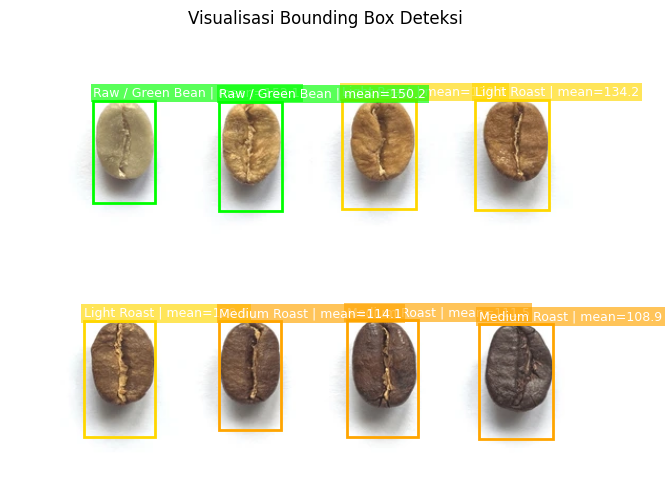

In [134]:
bg_val = 255
t_diff = 35
min_area = 500
show_visualization = True

real_gray = []
real_binary = []
real_bboxes = []
real_predictions = []
real_rgb = []
real_w = 0
real_h = 0

if not globals().get("real_file_path"):
    print("Path gambar belum diisi.")
elif not os.path.exists(real_file_path):
    print(f"File tidak ditemukan: {real_file_path}")
    print("Perbarui nilai real_file_path.")
else:
    real_rgb, real_w, real_h = load_rgb_image_file(real_file_path)

    real_gray, real_binary, real_bboxes, real_predictions = run_pipeline_on_real_rgb(
        real_rgb,
        bg_val=bg_val,
        t_diff=t_diff,
        min_area=min_area,
    )

    print(f"Ukuran gambar: {real_w}x{real_h}")
    print(f"Parameter segmentasi: bg_val={bg_val}, t_diff={t_diff}, min_area={min_area}")
    print(f"Jumlah objek terdeteksi: {len(real_predictions)}")

    for i, pred in enumerate(real_predictions, start=1):
        x1, y1, x2, y2 = pred["bbox"]
        print(
            f"Objek [{i}]: Bbox ({x1}, {y1}, {x2}, {y2}) | "
            f"Mean Intensity: {pred['mean_intensity']:.2f} | "
            f"Prediksi: {pred['label']}"
        )

    if show_visualization and len(real_predictions) > 0:
        visualize_detections_on_image(
            real_rgb,
            real_predictions,
            title="Visualisasi Bounding Box Deteksi",
        )
    elif show_visualization:
        print("Visualisasi dilewati karena belum ada objek terdeteksi.")

# 4.Evaluation Metrics

In [135]:
gt_real_boxes = [
    (75, 60, 140, 165),
    (195, 65, 260, 170),
    (315, 60, 385, 170),
    (440, 60, 515, 170),
    (70, 270, 140, 385),
    (195, 270, 260, 380),
    (320, 270, 390, 385),
    (445, 275, 515, 390)
]
gt_real_labels = [
    "Raw / Green Bean",
    "Light Roast",
    "Light Roast",
    "Light Roast",
    "Medium Roast",
    "Medium Roast",
    "Medium Dark Roast",
    "Dark Roast"
]

preds_eval = globals().get("real_predictions", [])

if len(preds_eval) == 0:
    print("Evaluasi Metrik")
    print("Belum ada prediksi.")
elif len(gt_real_boxes) == 0 or len(gt_real_boxes) != len(gt_real_labels):
    print("Evaluasi Metrik")
    print("Isi gt_real_boxes dan gt_real_labels dengan panjang yang sama.")
else:
    real_eval = evaluate_pipeline(
        predictions=preds_eval,
        gt_boxes=gt_real_boxes,
        gt_labels=gt_real_labels,
        iou_match_threshold=0.3,
    )

    print(f"Matched objects        : {real_eval['matched_count']} / {len(gt_real_boxes)}")
    print(f"Mean IoU               : {real_eval['mean_iou']:.4f}")
    print(f"Detection Precision    : {real_eval['detection_precision']:.4f}")
    print(f"Detection Recall       : {real_eval['detection_recall']:.4f}")

    cls_real = real_eval["classification"]
    print(f"Accuracy={cls_real['accuracy']:.4f}")

Matched objects        : 8 / 8
Mean IoU               : 0.8867
Detection Precision    : 1.0000
Detection Recall       : 1.0000
Accuracy=0.5000


# Analysis
Analisis Hasil Evaluasi Sistem Deteksi dan Klasifikasi Biji Kopi
Evaluasi sistem dilakukan dengan membandingkan hasil prediksi algoritma (Bounding Box dan Label Klasifikasi) terhadap data Ground Truth (GT) manual. Evaluasi dibagi menjadi dua aspek utama: performa deteksi objek dan performa klasifikasi fase roasting.

Analisis Performa Lokalisasi (Mean IoU, Precision, Recall)
Berdasarkan hasil pengujian, sistem menunjukkan performa deteksi objek yang baik dengan metrik berikut:

- Detection Precision (1.0000) & Recall (1.0000): Sistem berhasil melokalisasi 8 dari 8 biji kopi dengan sempurna. Nilai Precision 100% membuktikan bahwa filter min_area berhasil membuang semua noise (tidak ada False Positive), dan nilai Recall 100% membuktikan tidak ada satupun objek biji kopi yang terlewat oleh algoritma Connected Component Labeling (tidak ada False Negative).

- Mean Intersection over Union / IoU (0.8867): Nilai ini menunjukkan presisi batas koordinat kotak pendeteksi. Skor ~88% cukup tinggi untuk pendekatan Classical Computer Vision. Selisih (sekitar 12%) disebabkan oleh bentuk bounding box yang kaku (persegi) membungkus objek yang asimetris (oval), serta adanya toleransi bayangan tipis di sekitar tepi biji kopi yang ikut terhitung sebagai foreground.

Analisis Performa Klasifikasi (Accuracy)

Performa klasifikasi sistem berada pada angka Accuracy 0.5000 (50%) yang berarti dari 8 biji kopi yang berhasil dideteksi lokasinya, hanya 4 biji yang diprediksi fase roasting-nya dengan tepat sesuai Ground Truth.

Penurunan akurasi ini dapat dianalisis dari beberapa faktor teknis:

- Keterbatasan Ekstraksi Fitur 1-Dimensi: Sistem saat ini hanya mengandalkan satu fitur tunggal, yaitu Mean Grayscale Intensity (rata-rata kecerahan piksel). Pendekatan ini rentan terhadap highlight (pantulan cahaya putih pada permukaan kopi yang berminyak, terutama pada biji Dark Roast), yang menyebabkan rata-rata kecerahan membiaskan nilai aslinya menjadi lebih tinggi.

- Threshold yang Kaku (Hardcoded): Aturan rentang if-elif-else yang bersifat statis kurang fleksibel untuk mengatasi variasi pencahayaan ruangan saat pengambilan gambar (illumination variance). Sebuah biji Medium Roast dapat dengan mudah tergelincir ke kategori Light Roast hanya karena tertimpa cahaya lampu yang sedikit lebih terang.

Kesimpulan: Pendekatan Thresholding dan Connected Component Labeling tanpa library terbukti cukup tangguh dan komputasional ringan untuk lokalisasi objek. Namun, untuk tahap klasifikasi multi-class, ekstraksi fitur tunggal (rata-rata grayscale) memiliki keterbatasan. Pengembangan selanjutnya disarankan menggunakan ekstraksi fitur tambahan seperti variansi tekstur atau metrik warna dalam ruang HSV untuk mengkompensasi masalah pantulan cahaya. Selain itu, gambar yang digunakan juga terbilang optimal jika dibandingkan dengan kebanyakan kasus dimana setiap biji kopi terisolasi sendiri-sendiri.